# 12 Literature Augmented Graph

## Цель этапа

Этот этап расширяет explainability-граф из `09_knowledge_graph_explainability.ipynb` дополнительными признаками, извлеченными из русскоязычных агрономических источников по предшественникам культур и логике севооборота.

Важно зафиксировать границы интерпретации:

- новый literature-aware слой **не заменяет** CatBoost и не меняет shortlist-кандидатов;
- новый слой **не превращает** работу в экспертный агрономический оптимизатор;
- литературные сигналы используются как **дополнительное support/warning evidence** поверх data-driven explainability из stage 09;
- `graph_support_score` на этом этапе пересчитывается только внутри explainability-слоя и сохраняется отдельно от базового score из `09`.


## Использованные русскоязычные источники

Ниже перечислены источники, из которых вручную извлекались literature-backed правила переходов. Эти источники используются только как интерпретационный слой и не подменяют data-driven transition edges.

1. **Передириева Г.А. `Севообороты — основа земледелия`**, Ставропольский ГАУ.
   - URL: `https://old.stgau.ru/company/personal/user/6767/files/element/historyget/212248/№%20298_СЕВООБОРОТЫ%20%20Передириева%20по%20одной.pdf`
   - Покрытие: `wheat`, `other_cereals`, `corn`, `sorghum`, `legumes`, `fallow`, а также group-level логика по насыщению звеньев.
   - Извлеченные сигналы: `good predecessor`, `undesirable predecessor`, мягкие `warning` по повтору, общая логика разрыва зерновых/технических звеньев.
   - Использование: часть правил применяется напрямую, часть как `group_approx` для агрегированных классов проекта.

2. **Учебный материал КубГАУ по агротехнологии сои**.
   - URL поиска/размещения: `https://kubsau.ru/`
   - Покрытие: `soybeans`, а также переходы вида `corn -> soybeans`.
   - Извлеченные сигналы: `good predecessor` / `acceptable predecessor` для сои после зерновых и кукурузы.
   - Использование: правило `corn -> soybeans` используется как `direct` support.

3. **Русскоязычные исследования по предшественникам озимой пшеницы**.
   - Используются как подтверждающий источник для сильных предшественников `wheat` после `fallow` и травяного звена.
   - Извлеченные сигналы: `good predecessor`, `strong support` для `fallow -> wheat` и `forage_hay -> wheat`.
   - Использование: для агрегированного класса `wheat` часть правил вводится как `group_approx`.

4. **Русскоязычные источники по хлопчатнику в хлопководческом и орошаемом контексте**.
   - URL: `https://cyberleninka.ru/article/n/osobennosti-tehnologii-vozdelyvaniya-hlopchatnika-na-oroshaemyh-zemlyah`
   - Покрытие: прямые переходы `legumes -> cotton` и `forage_hay -> cotton`.
   - Извлеченные сигналы: `good predecessor`, `strong support` для размещения хлопчатника после бобовых и люцернового/кормового звена.
   - Использование: для `cotton` эти правила используются как `direct`, но с обязательной текстовой пометкой в `zonal_note`, что речь идет о хлопководческих и орошаемых регионах.

5. **Русскоязычные источники по повторному размещению хлопчатника и узкому хлопково-зерновому звену**.
   - URL: `https://cyberleninka.ru/article/n/vliyanie-povtornyh-kultur-na-plodorodie-pochvy-i-produktivnost-sortov-hlopchatnika`
   - Дополнительный URL: `https://cyberleninka.ru/article/n/problemy-zaschity-rasteniy-v-uzbekistane`
   - Покрытие: прямые переходы `cotton -> cotton` и `wheat -> cotton`.
   - Извлеченные сигналы: `warning` против повторного размещения хлопчатника и warning для слишком узкой схемы `wheat -> cotton` в зональном фитосанитарном контексте.
   - Использование: эти правила также используются как `direct`, но не как универсальные, а как зонально ограниченные.

### Замечание по соответствию target-space проекта

- `corn`, `soybeans`, `wheat` имеют относительно прямые literature-backed сигналы;
- `legumes`, `other_cereals`, `forage_hay`, `fallow` частично используют агрегированное сопоставление;
- `cotton` в этом notebook имеет прямые literature-backed правила, но они сохраняют зональную оговорку через `zonal_note` и не должны трактоваться как универсальные для всех регионов.


In [13]:
from __future__ import annotations

import ast
import json
import re
from pathlib import Path

from IPython.display import Image as IPImage
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_CWD = Path.cwd().resolve()
ROOT = None
for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError(
        f"Could not resolve repository root from cwd={NOTEBOOK_CWD}. Expected a parent containing both 'artifacts' and 'notebooks'."
    )
print(f"Resolved repository root: {ROOT}")
BASE_RESULTS_DIR = ROOT / "artifacts" / "results" / "knowledge_graph_explainability"
RESULTS_DIR = ROOT / "artifacts" / "results" / "literature_graph"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CASE_EXPLANATIONS_PATH = BASE_RESULTS_DIR / "case_explanations.csv"
CASE_SUMMARY_PATH = BASE_RESULTS_DIR / "case_summary.csv"
KG_NODES_PATH = BASE_RESULTS_DIR / "kg_nodes.csv"
KG_EDGES_PATH = BASE_RESULTS_DIR / "kg_edges.csv"
KG_RULES_PATH = BASE_RESULTS_DIR / "kg_rules.csv"
TRANSITION_EDGES_PATH = BASE_RESULTS_DIR / "transition_edges.csv"
RUN_META_PATH = BASE_RESULTS_DIR / "run_meta.json"
LITERATURE_RULES_PATH = RESULTS_DIR / "literature_transition_rules.csv"
LITERATURE_SOURCES_PATH = RESULTS_DIR / "literature_sources.json"

REQUIRED_BASE_PATHS = [
    CASE_EXPLANATIONS_PATH,
    CASE_SUMMARY_PATH,
    KG_NODES_PATH,
    KG_EDGES_PATH,
    KG_RULES_PATH,
    TRANSITION_EDGES_PATH,
    RUN_META_PATH,
    LITERATURE_RULES_PATH,
]
missing_paths = [str(p) for p in REQUIRED_BASE_PATHS if not p.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing required inputs: {missing_paths}")

SOURCE_META = [
    {
        "source_id": "stgau_rotation_basics",
        "citation": "Передириева Г.А. Севообороты — основа земледелия. Ставропольский ГАУ.",
        "url": "https://old.stgau.ru/company/personal/user/6767/files/element/historyget/212248/№%20298_СЕВООБОРОТЫ%20%20Передириева%20по%20одной.pdf",
        "coverage": ["wheat", "other_cereals", "corn", "sorghum", "legumes", "fallow", "group:industrial"],
        "signal_types": ["good predecessor", "undesirable predecessor", "warning", "group_approx"],
    },
    {
        "source_id": "kubsau_soy_predecessors",
        "citation": "Русскоязычный учебный материал КубГАУ по предшественникам сои.",
        "url": "https://kubsau.ru/",
        "coverage": ["soybeans", "corn -> soybeans"],
        "signal_types": ["good predecessor", "acceptable predecessor"],
    },
    {
        "source_id": "wheat_predecessor_study",
        "citation": "Русскоязычные исследования по предшественникам озимой пшеницы и их влиянию на урожайность.",
        "url": "https://cyberleninka.ru/",
        "coverage": ["wheat", "forage_hay -> wheat", "fallow -> wheat"],
        "signal_types": ["good predecessor", "strong support"],
    },
    {
        "source_id": "cotton_irrigated_technology",
        "citation": "Особенности технологии возделывания хлопчатника на орошаемых землях.",
        "url": "https://cyberleninka.ru/article/n/osobennosti-tehnologii-vozdelyvaniya-hlopchatnika-na-oroshaemyh-zemlyah",
        "coverage": ["legumes -> cotton", "forage_hay -> cotton"],
        "signal_types": ["good predecessor", "strong support", "direct", "zonal"],
    },
    {
        "source_id": "cotton_repeat_crop_study",
        "citation": "Влияние повторных культур на плодородие почвы и продуктивность сортов хлопчатника.",
        "url": "https://cyberleninka.ru/article/n/vliyanie-povtornyh-kultur-na-plodorodie-pochvy-i-produktivnost-sortov-hlopchatnika",
        "coverage": ["cotton -> cotton"],
        "signal_types": ["warning", "direct", "zonal"],
    },
    {
        "source_id": "cotton_pest_rotation_uzbekistan",
        "citation": "Проблемы защиты растений в Узбекистане.",
        "url": "https://cyberleninka.ru/article/n/problemy-zaschity-rasteniy-v-uzbekistane",
        "coverage": ["wheat -> cotton"],
        "signal_types": ["warning", "direct", "zonal"],
    },
]

with LITERATURE_SOURCES_PATH.open("w", encoding="utf-8") as f:
    json.dump(SOURCE_META, f, ensure_ascii=False, indent=2)

case_explanations_df = pd.read_csv(CASE_EXPLANATIONS_PATH)
case_summary_df = pd.read_csv(CASE_SUMMARY_PATH)
kg_nodes_df = pd.read_csv(KG_NODES_PATH)
kg_edges_df = pd.read_csv(KG_EDGES_PATH)
kg_rules_df = pd.read_csv(KG_RULES_PATH)
transition_edges_df = pd.read_csv(TRANSITION_EDGES_PATH)
literature_rules_df = pd.read_csv(LITERATURE_RULES_PATH)
base_run_meta = json.loads(RUN_META_PATH.read_text(encoding="utf-8"))

required_case_cols = {
    "case_label", "candidate", "score", "candidate_rank", "is_model_top1", "is_true_target",
    "crop_group", "transition_prob", "region_share", "region_rank", "support_flags",
    "warning_flags", "graph_support_score", "graph_support_level", "short_explanation",
}
missing_case_cols = sorted(required_case_cols - set(case_explanations_df.columns))
if missing_case_cols:
    raise ValueError(f"case_explanations.csv is missing columns: {missing_case_cols}")

required_lit_cols = {
    "rule_id", "source_id", "source_title_short", "crop_context", "candidate", "signal_type",
    "strength", "mapping_level", "zonal_note", "evidence_text_short",
}
missing_lit_cols = sorted(required_lit_cols - set(literature_rules_df.columns))
if missing_lit_cols:
    raise ValueError(f"literature_transition_rules.csv is missing columns: {missing_lit_cols}")

print("Loaded base case rows:", len(case_explanations_df))
print("Loaded base cases:", case_explanations_df["case_label"].nunique())
print("Loaded literature rules:", len(literature_rules_df))
display(literature_rules_df.head())


Resolved repository root: C:\Users\Dmitry\code-projects\diploma-crop-rotation
Loaded base case rows: 12
Loaded base cases: 4
Loaded literature rules: 15


,rule_id,source_id,source_title_short,crop_context,candidate,signal_type,strength,mapping_level,zonal_note,evidence_text_short
0,lit_rule_001,stgau_rotation_basics,Севообороты — основа земледелия,forage_hay,wheat,support,strong,group_approx,Более уместно для зернопаровых и зернотравяных...,Многолетние травы рассматриваются как сильный ...
1,lit_rule_002,stgau_rotation_basics,Севообороты — основа земледелия,forage_hay,forage_hay,warning,medium,group_approx,Повтор кормовой группы зависит от типа травост...,Повтор той же кормовой группы подряд снижает р...
2,lit_rule_003,stgau_rotation_basics,Севообороты — основа земледелия,corn,corn,warning,strong,direct,Особенно важно для насыщенных пропашных/зернов...,Повтор кукурузы подряд рассматривается как неж...
3,lit_rule_004,kubsau_soy_predecessors,Предшественники сои в агротехнологии КубГАУ,corn,soybeans,support,strong,direct,Опора на русскоязычный учебный материал по сое...,Кукуруза может выступать приемлемым или хороши...
4,lit_rule_005,stgau_rotation_basics,Севообороты — основа земледелия,corn,legumes,support,medium,group_approx,Используется как групповое приближение для агр...,Зерновые и пропашные звенья часто разрываются ...


In [14]:
CROP_TO_GROUP = {
    "corn": "cereal",
    "cotton": "industrial",
    "fallow": "fallow",
    "forage_hay": "forage",
    "legumes": "legume",
    "other_cereals": "cereal",
    "sorghum": "cereal",
    "soybeans": "legume",
    "wheat": "cereal",
}

GRAPH_SCORE_WEIGHTS = {
    "transition": 0.50,
    "region_share": 0.30,
    "region_rank": 0.10,
    "support_bonus": 0.04,
    "warning_penalty": 0.05,
}
GRAPH_ALIGNMENT_MARGIN = 0.08
LITERATURE_STRENGTH_WEIGHTS = {"weak": 0.01, "medium": 0.02, "strong": 0.03}

def parse_listlike(value):
    if isinstance(value, list):
        return value
    if pd.isna(value) or value == "":
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

def extract_last_crop(text: str) -> str | None:
    if pd.isna(text):
        return None
    m = re.search(r"Observed transition\s+([a-z_]+)\s*->\s*([a-z_]+)", str(text))
    return m.group(1) if m else None

def match_context(context_value: str, crop_name: str, crop_group: str) -> bool:
    if not isinstance(context_value, str) or not context_value:
        return False
    if context_value.startswith("group:"):
        return crop_group == context_value.split(":", 1)[1]
    return crop_name == context_value

def normalize_signal_type(signal_type: str) -> str:
    signal_type = str(signal_type).strip().lower()
    if signal_type in {"support", "good_predecessor", "return_interval", "acceptable_predecessor"}:
        return "support"
    return "warning"

def compute_graph_support_score(transition_prob, region_share, region_rank, support_flags, warning_flags):
    transition_norm = 0.0 if pd.isna(transition_prob) else float(np.clip(float(transition_prob), 0.0, 1.0))
    region_norm = 0.0 if pd.isna(region_share) else float(np.clip(float(region_share), 0.0, 1.0))
    if pd.isna(region_rank):
        region_rank_norm = 0.0
    else:
        region_rank_norm = float(np.clip((4.0 - float(region_rank)) / 3.0, 0.0, 1.0))
    support_bonus = GRAPH_SCORE_WEIGHTS["support_bonus"] * min(len(support_flags), 3)
    warning_penalty = GRAPH_SCORE_WEIGHTS["warning_penalty"] * min(len(warning_flags), 3)
    score = (
        GRAPH_SCORE_WEIGHTS["transition"] * transition_norm
        + GRAPH_SCORE_WEIGHTS["region_share"] * region_norm
        + GRAPH_SCORE_WEIGHTS["region_rank"] * region_rank_norm
        + support_bonus
        - warning_penalty
    )
    return float(np.clip(score, 0.0, 1.0))

def resolve_graph_support_level(score: float) -> str:
    if score >= 0.66:
        return "strong"
    if score >= 0.33:
        return "moderate"
    return "weak"

def compute_alignment(df: pd.DataFrame, score_col: str, margin: float = GRAPH_ALIGNMENT_MARGIN) -> str:
    if df.empty:
        return "weak"
    top1_row = df[df["is_model_top1"]].head(1)
    if top1_row.empty:
        return "weak"
    top1_score = float(top1_row[score_col].iloc[0])
    best_score = float(df[score_col].max())
    alt_df = df[~df["is_model_top1"]]
    best_alt_score = float(alt_df[score_col].max()) if not alt_df.empty else top1_score
    if top1_score >= best_score - 1e-9:
        return "strong"
    if (best_alt_score - top1_score) <= float(margin):
        return "medium"
    return "weak"

case_aug_df = case_explanations_df.copy()
case_aug_df["support_flags"] = case_aug_df["support_flags"].apply(parse_listlike)
case_aug_df["warning_flags"] = case_aug_df["warning_flags"].apply(parse_listlike)
case_aug_df["last_crop"] = case_aug_df["short_explanation"].apply(extract_last_crop)
case_aug_df["last_crop_group"] = case_aug_df["last_crop"].map(CROP_TO_GROUP)
case_aug_df["candidate_group_mapped"] = case_aug_df["candidate"].map(CROP_TO_GROUP).fillna(case_aug_df["crop_group"])
case_aug_df["base_graph_support_score"] = case_aug_df["graph_support_score"].astype(float)
case_aug_df["base_graph_support_level"] = case_aug_df["graph_support_level"]

aug_rows = []
for row in case_aug_df.to_dict(orient="records"):
    matched_rules = []
    for _, lit_rule in literature_rules_df.iterrows():
        crop_match = match_context(str(lit_rule["crop_context"]), str(row["last_crop"]), str(row["last_crop_group"]))
        cand_match = match_context(str(lit_rule["candidate"]), str(row["candidate"]), str(row["candidate_group_mapped"]))
        if crop_match and cand_match:
            matched_rules.append(lit_rule.to_dict())

    literature_support_rules = [r for r in matched_rules if normalize_signal_type(r["signal_type"]) == "support"]
    literature_warning_rules = [r for r in matched_rules if normalize_signal_type(r["signal_type"]) == "warning"]
    literature_support_flags = [r["rule_id"] for r in literature_support_rules]
    literature_warning_flags = [r["rule_id"] for r in literature_warning_rules]

    combined_support_flags = list(row["support_flags"]) + literature_support_flags
    combined_warning_flags = list(row["warning_flags"]) + literature_warning_flags

    literature_strength_bonus = sum(LITERATURE_STRENGTH_WEIGHTS.get(str(r["strength"]).lower(), 0.0) for r in literature_support_rules)
    literature_strength_penalty = sum(LITERATURE_STRENGTH_WEIGHTS.get(str(r["strength"]).lower(), 0.0) for r in literature_warning_rules)

    literature_graph_support_score = compute_graph_support_score(
        row["transition_prob"],
        row["region_share"],
        row["region_rank"],
        combined_support_flags,
        combined_warning_flags,
    )
    literature_graph_support_score = float(np.clip(
        literature_graph_support_score + literature_strength_bonus - literature_strength_penalty,
        0.0,
        1.0,
    ))

    literature_evidence_bits = [
        f"[{r['source_id']}] {r['evidence_text_short']}"
        for r in matched_rules
    ]
    row["literature_support_flags"] = literature_support_flags
    row["literature_warning_flags"] = literature_warning_flags
    row["combined_support_flags"] = combined_support_flags
    row["combined_warning_flags"] = combined_warning_flags
    row["literature_strength_bonus"] = literature_strength_bonus
    row["literature_strength_penalty"] = literature_strength_penalty
    row["literature_graph_support_score"] = literature_graph_support_score
    row["literature_graph_support_level"] = resolve_graph_support_level(literature_graph_support_score)
    row["delta_graph_support_score"] = literature_graph_support_score - float(row["base_graph_support_score"])
    row["literature_evidence_summary"] = " ".join(literature_evidence_bits)
    row["literature_short_explanation"] = (
        str(row["short_explanation"]) +
        (" Literature-backed evidence: " + " ".join(literature_evidence_bits) if literature_evidence_bits else "")
    )
    aug_rows.append(row)

literature_augmented_case_explanations_df = pd.DataFrame(aug_rows)

summary_rows = []
for case_label, cdf in literature_augmented_case_explanations_df.groupby("case_label", sort=False):
    cdf = cdf.sort_values(["candidate_rank", "score"])
    top1_row = cdf[cdf["is_model_top1"]].iloc[0]
    best_lit_row = cdf.sort_values(["literature_graph_support_score", "score"], ascending=[False, False]).iloc[0]
    literature_alignment = compute_alignment(cdf, "literature_graph_support_score")
    triggered_rules = sorted(set(sum(cdf["literature_support_flags"].tolist(), []) + sum(cdf["literature_warning_flags"].tolist(), [])))
    summary_rows.append({
        "case_label": case_label,
        "target": cdf["candidate"].loc[cdf["is_true_target"]].iloc[0] if cdf["is_true_target"].any() else None,
        "model_top1": top1_row["candidate"],
        "base_top1_graph_support_score": float(top1_row["base_graph_support_score"]),
        "literature_top1_graph_support_score": float(top1_row["literature_graph_support_score"]),
        "base_top1_graph_alignment": str(cdf["top1_graph_alignment"].iloc[0]),
        "literature_top1_graph_alignment": literature_alignment,
        "best_literature_candidate": best_lit_row["candidate"],
        "best_literature_graph_support_score": float(best_lit_row["literature_graph_support_score"]),
        "graph_support_gap_best_minus_top1_literature": float(best_lit_row["literature_graph_support_score"] - top1_row["literature_graph_support_score"]),
        "n_triggered_literature_rules": len(triggered_rules),
        "triggered_literature_rules": triggered_rules,
        "case_literature_summary": (
            f"Base alignment={cdf['top1_graph_alignment'].iloc[0]}, literature alignment={literature_alignment}. "
            f"Top-1 {top1_row['candidate']} changed by {float(top1_row['delta_graph_support_score']):+.3f}. "
            f"Best literature-supported candidate is {best_lit_row['candidate']} (gs={float(best_lit_row['literature_graph_support_score']):.3f})."
        ),
    })

literature_augmented_case_summary_df = pd.DataFrame(summary_rows)

comparison_df = literature_augmented_case_explanations_df[[
    "case_label", "candidate", "candidate_rank", "is_model_top1", "is_true_target",
    "base_graph_support_score", "literature_graph_support_score", "delta_graph_support_score",
    "top1_graph_alignment", "literature_support_flags", "literature_warning_flags", "literature_evidence_summary",
]].copy()

display(literature_augmented_case_summary_df)
display(comparison_df.head(12))


,case_label,target,model_top1,base_top1_graph_support_score,literature_top1_graph_support_score,base_top1_graph_alignment,literature_top1_graph_alignment,best_literature_candidate,best_literature_graph_support_score,graph_support_gap_best_minus_top1_literature,n_triggered_literature_rules,triggered_literature_rules,case_literature_summary
0,case_high_confidence,forage_hay,forage_hay,0.660545,0.590545,strong,strong,forage_hay,0.590545,0.000000,3,"[lit_rule_001, lit_rule_002, lit_rule_008]","Base alignment=strong, literature alignment=st..."
1,case_medium_confidence,corn,corn,0.375989,0.235989,weak,weak,soybeans,0.598123,0.362135,4,"[lit_rule_003, lit_rule_004, lit_rule_012, lit...","Base alignment=weak, literature alignment=weak..."
2,case_low_confidence,legumes,legumes,0.010571,0.070571,weak,weak,soybeans,0.698460,0.627889,3,"[lit_rule_004, lit_rule_005, lit_rule_012]","Base alignment=weak, literature alignment=weak..."
3,case_difficult_class,soybeans,corn,0.219969,0.219969,weak,weak,soybeans,0.386288,0.166319,1,[lit_rule_011],"Base alignment=weak, literature alignment=weak..."


,case_label,candidate,candidate_rank,is_model_top1,is_true_target,base_graph_support_score,literature_graph_support_score,delta_graph_support_score,top1_graph_alignment,literature_support_flags,literature_warning_flags,literature_evidence_summary
0,case_high_confidence,forage_hay,1,True,True,0.660545,0.590545,-7.000000e-02,strong,[],[lit_rule_002],[stgau_rotation_basics] Повтор той же кормовой...
1,case_high_confidence,corn,2,False,False,0.067884,0.067884,2.775558e-17,strong,[],[],
2,case_high_confidence,wheat,3,False,False,0.135650,0.275650,1.400000e-01,strong,"[lit_rule_001, lit_rule_008]",[],[stgau_rotation_basics] Многолетние травы расс...
3,case_medium_confidence,corn,1,True,True,0.375989,0.235989,-1.400000e-01,weak,[],"[lit_rule_003, lit_rule_013]",[stgau_rotation_basics] Повтор кукурузы подряд...
4,case_medium_confidence,soybeans,2,False,False,0.508123,0.598123,9.000000e-02,weak,"[lit_rule_004, lit_rule_012]",[],[kubsau_soy_predecessors] Кукуруза может высту...
5,case_medium_confidence,forage_hay,3,False,False,0.148390,0.148390,-5.551115e-17,weak,[],[],
6,case_low_confidence,legumes,1,True,True,0.010571,0.070571,6.000000e-02,weak,[lit_rule_005],[],[stgau_rotation_basics] Зерновые и пропашные з...
7,case_low_confidence,soybeans,2,False,False,0.568460,0.698460,1.300000e-01,weak,"[lit_rule_004, lit_rule_012]",[],[kubsau_soy_predecessors] Кукуруза может высту...
8,case_low_confidence,fallow,3,False,False,0.125709,0.125709,0.000000e+00,weak,[],[],
9,case_difficult_class,corn,1,True,False,0.219969,0.219969,-5.551115e-17,weak,[],[],


Saved literature-aware outputs to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph


,case_label,target,model_top1,base_top1_graph_support_score,literature_top1_graph_support_score,base_top1_graph_alignment,literature_top1_graph_alignment,best_literature_candidate,best_literature_graph_support_score,graph_support_gap_best_minus_top1_literature,n_triggered_literature_rules,triggered_literature_rules,case_literature_summary
0,case_high_confidence,forage_hay,forage_hay,0.660545,0.590545,strong,strong,forage_hay,0.590545,0.000000,3,"[lit_rule_001, lit_rule_002, lit_rule_008]","Base alignment=strong, literature alignment=st..."
1,case_medium_confidence,corn,corn,0.375989,0.235989,weak,weak,soybeans,0.598123,0.362135,4,"[lit_rule_003, lit_rule_004, lit_rule_012, lit...","Base alignment=weak, literature alignment=weak..."
2,case_low_confidence,legumes,legumes,0.010571,0.070571,weak,weak,soybeans,0.698460,0.627889,3,"[lit_rule_004, lit_rule_005, lit_rule_012]","Base alignment=weak, literature alignment=weak..."
3,case_difficult_class,soybeans,corn,0.219969,0.219969,weak,weak,soybeans,0.386288,0.166319,1,[lit_rule_011],"Base alignment=weak, literature alignment=weak..."


Inline case-study figures:
- case_high_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_high_confidence_literature_graph.png


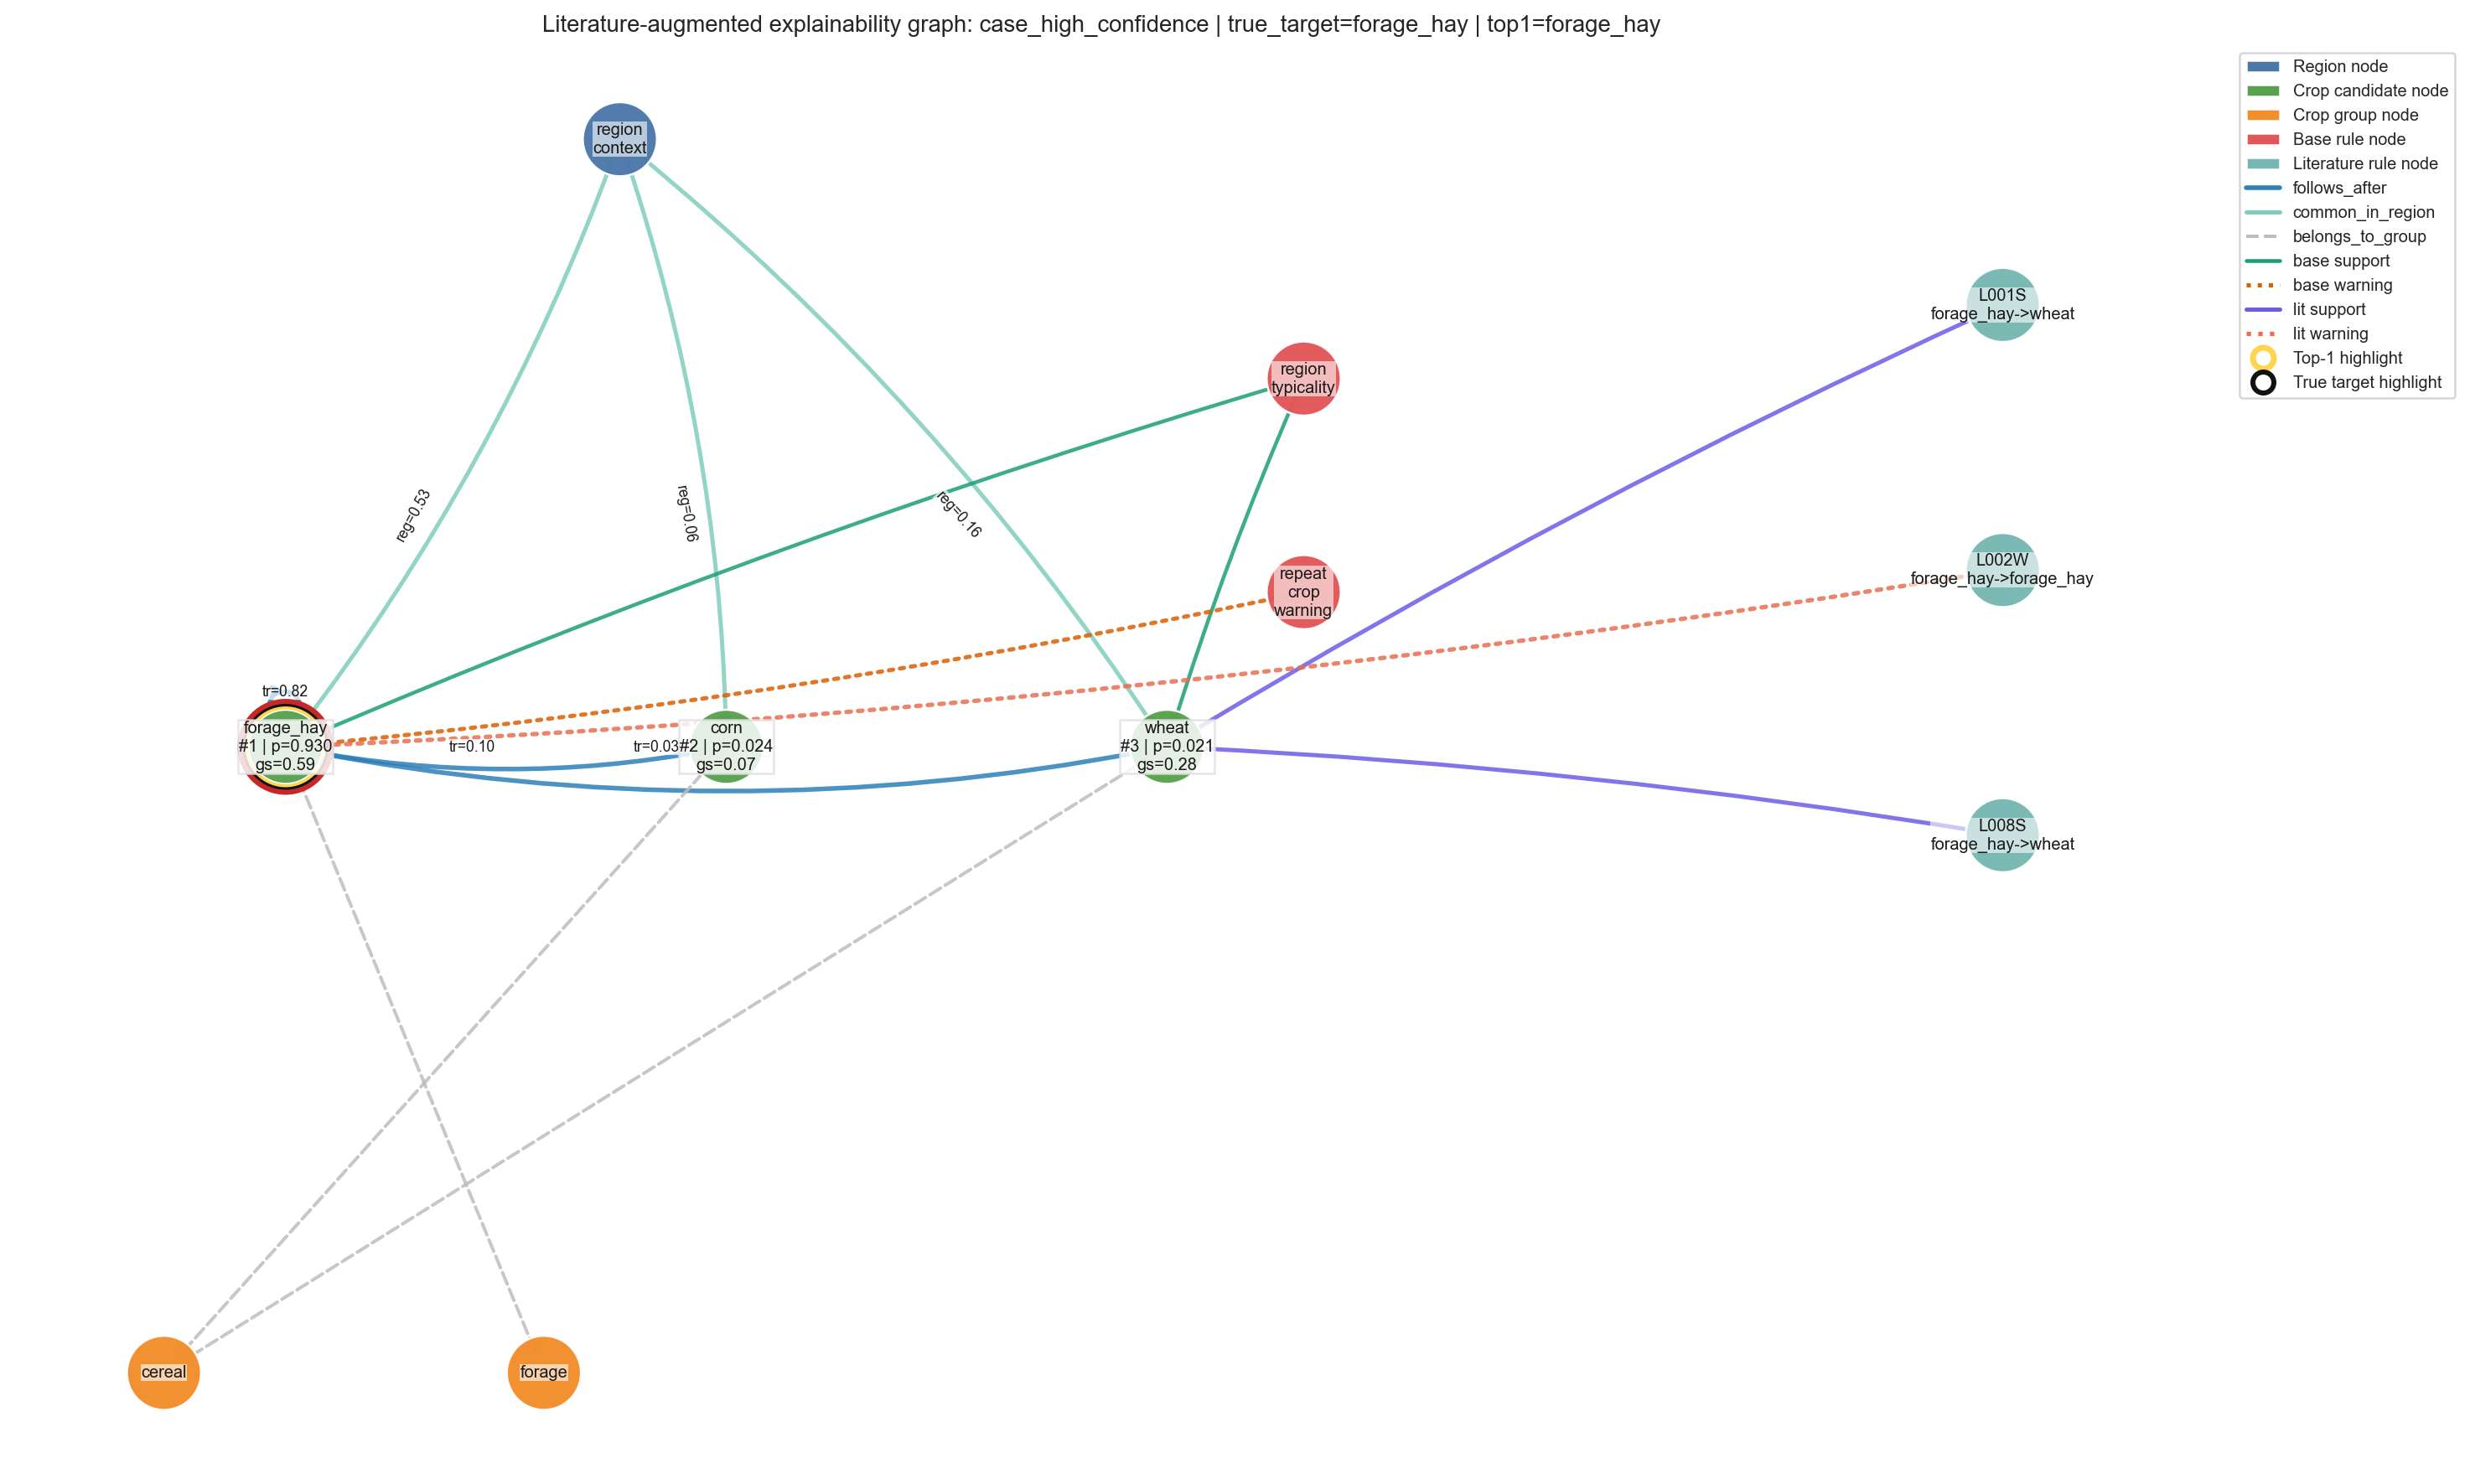

- case_medium_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_medium_confidence_literature_graph.png


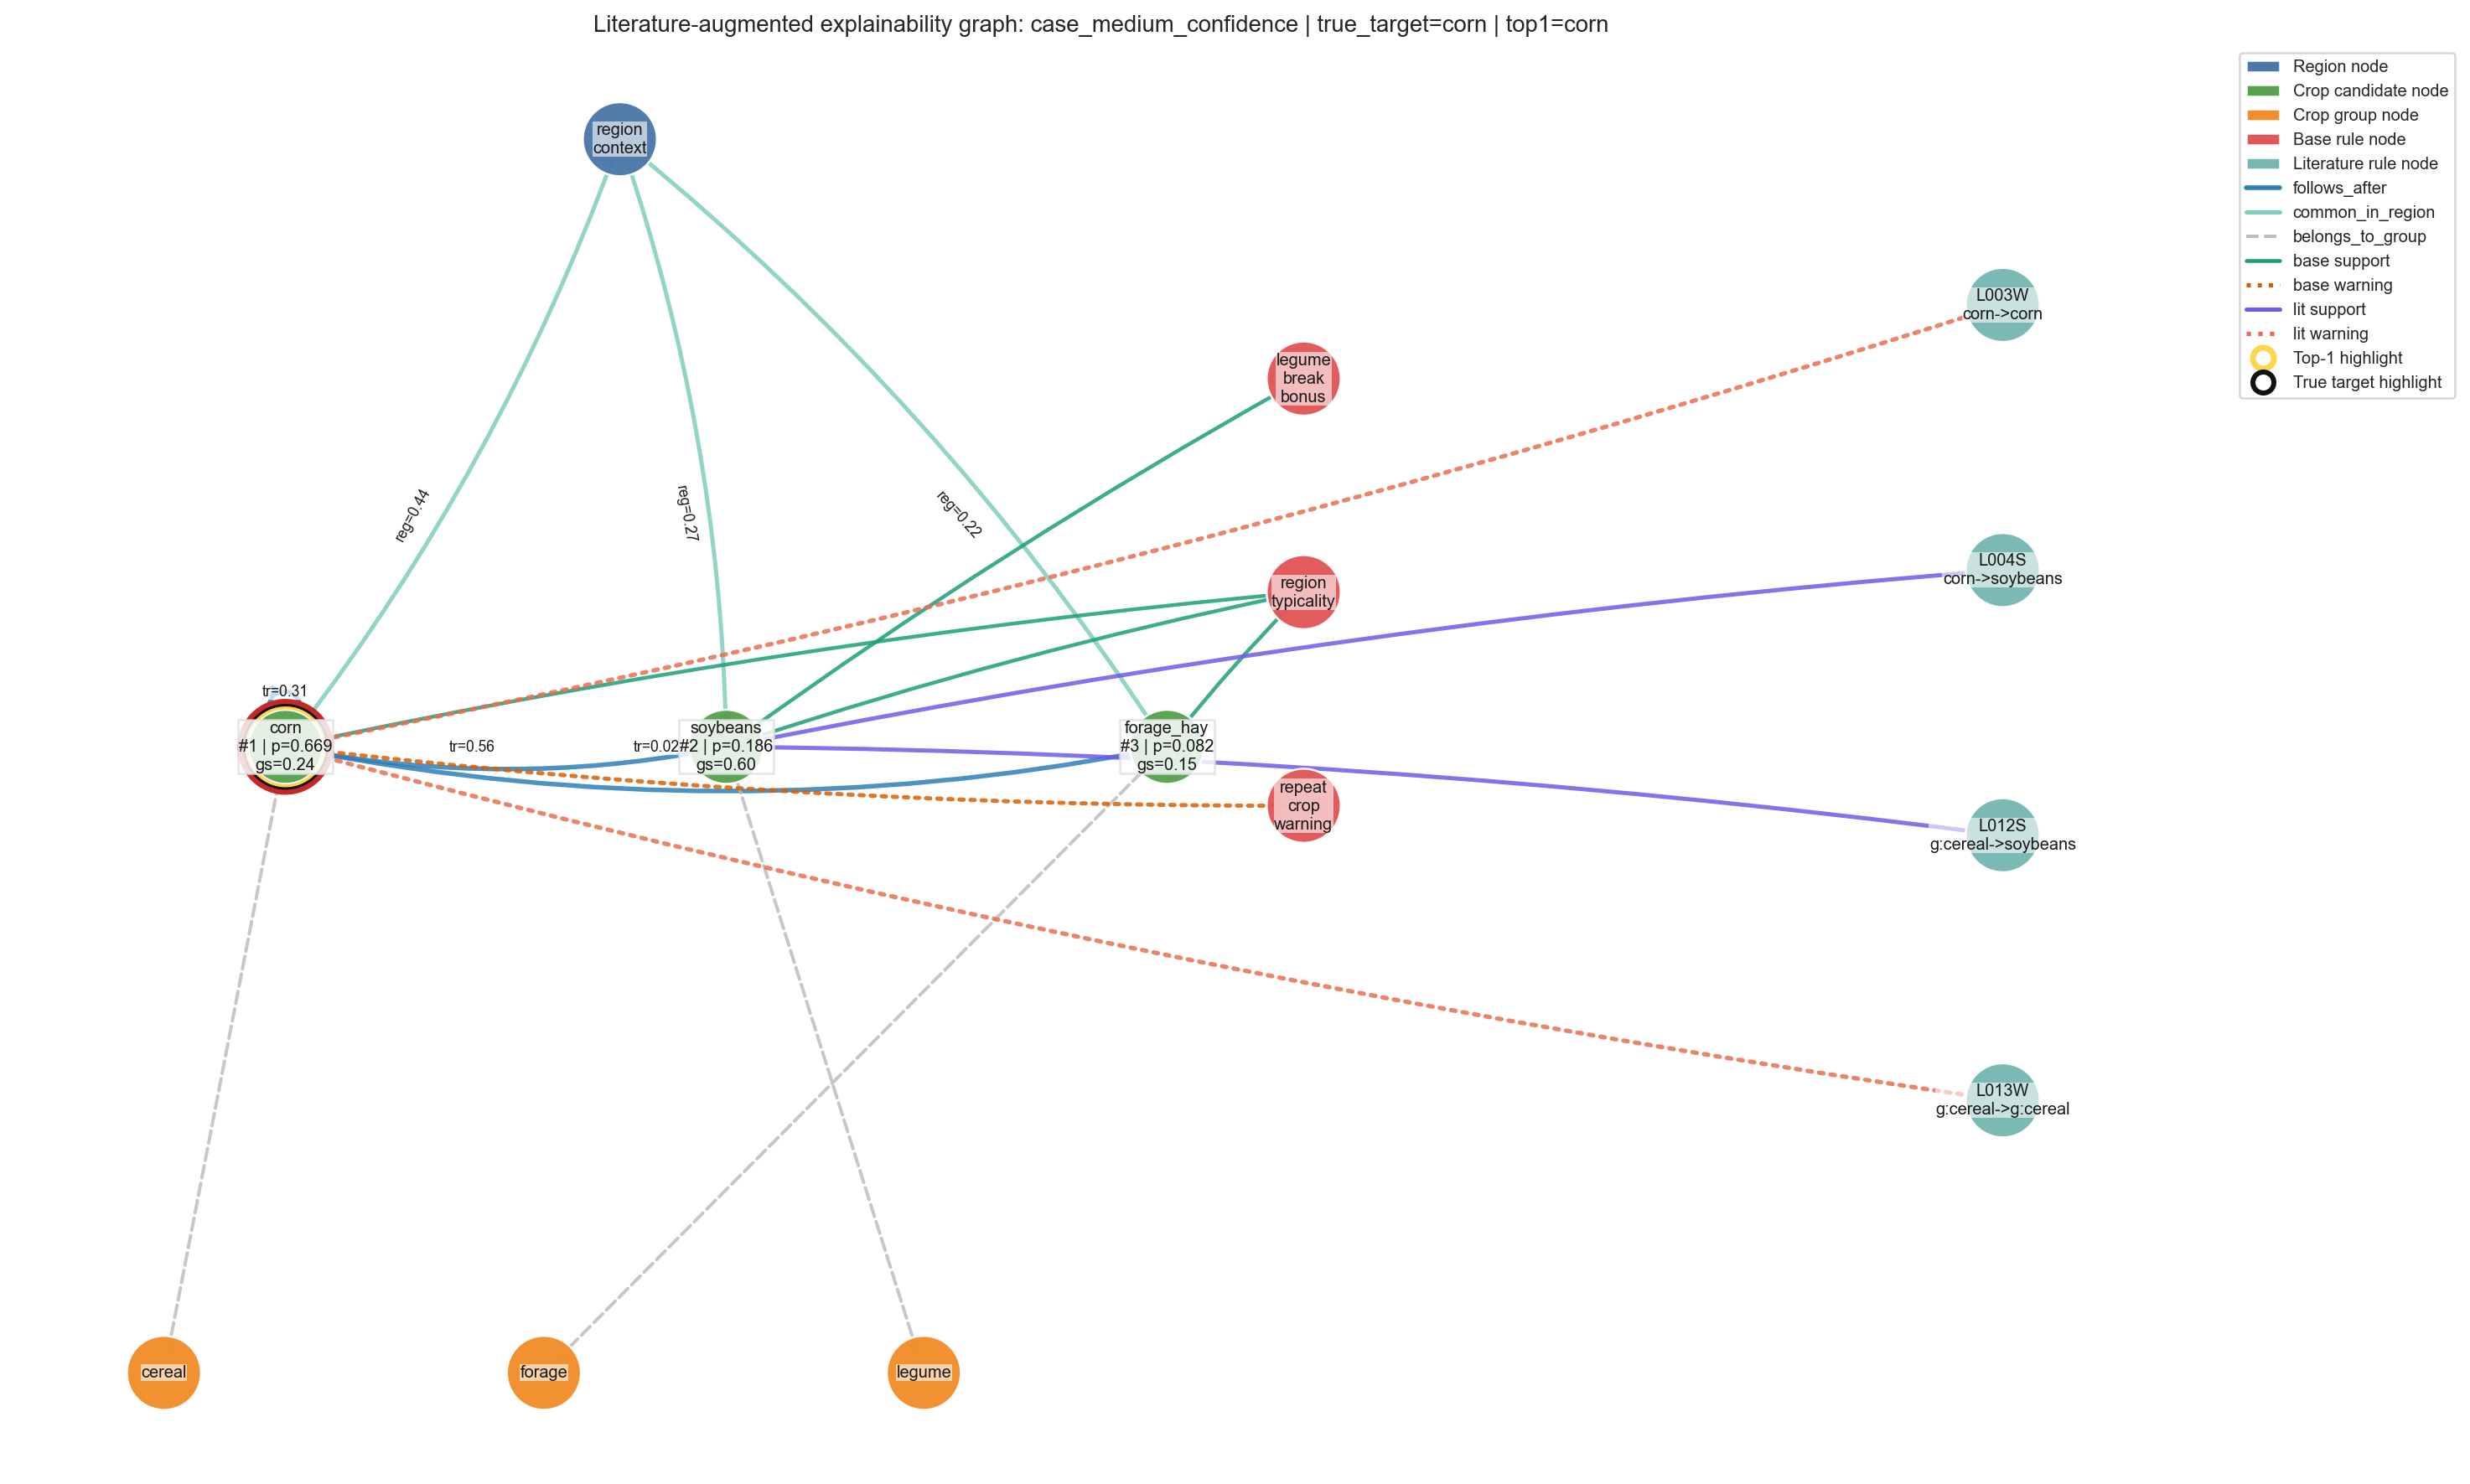

- case_low_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_low_confidence_literature_graph.png


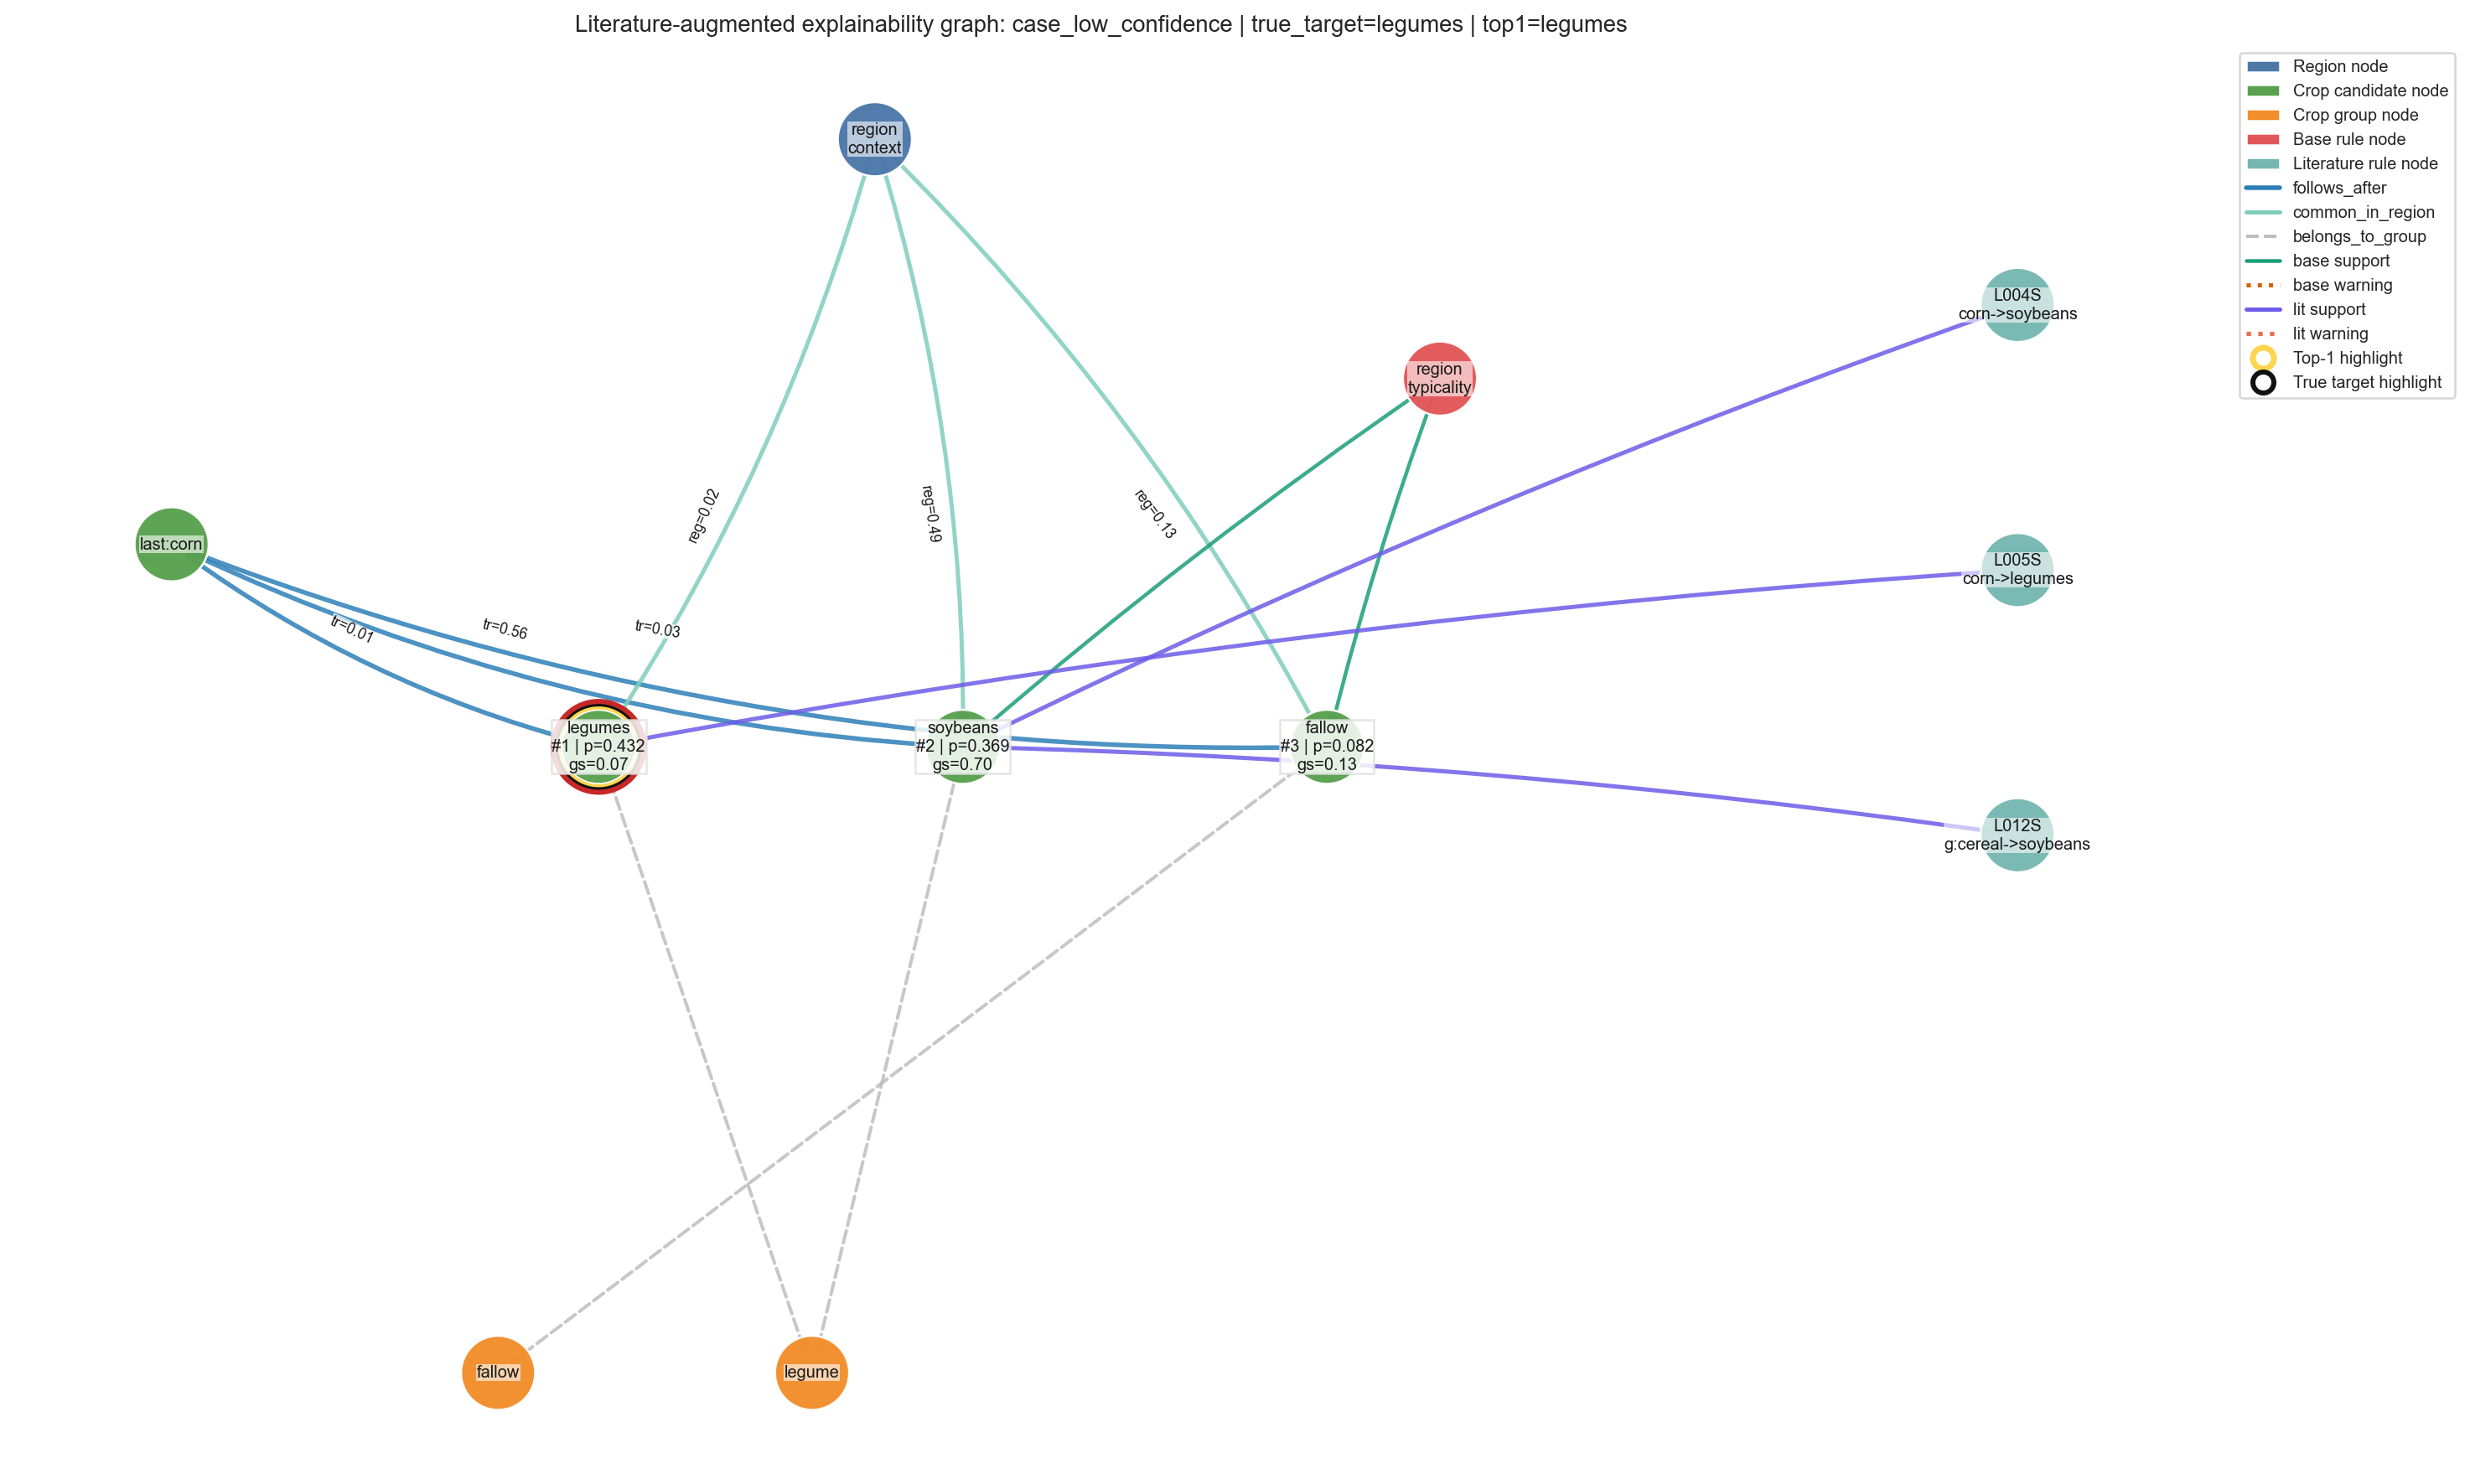

- case_difficult_class: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_difficult_class_literature_graph.png


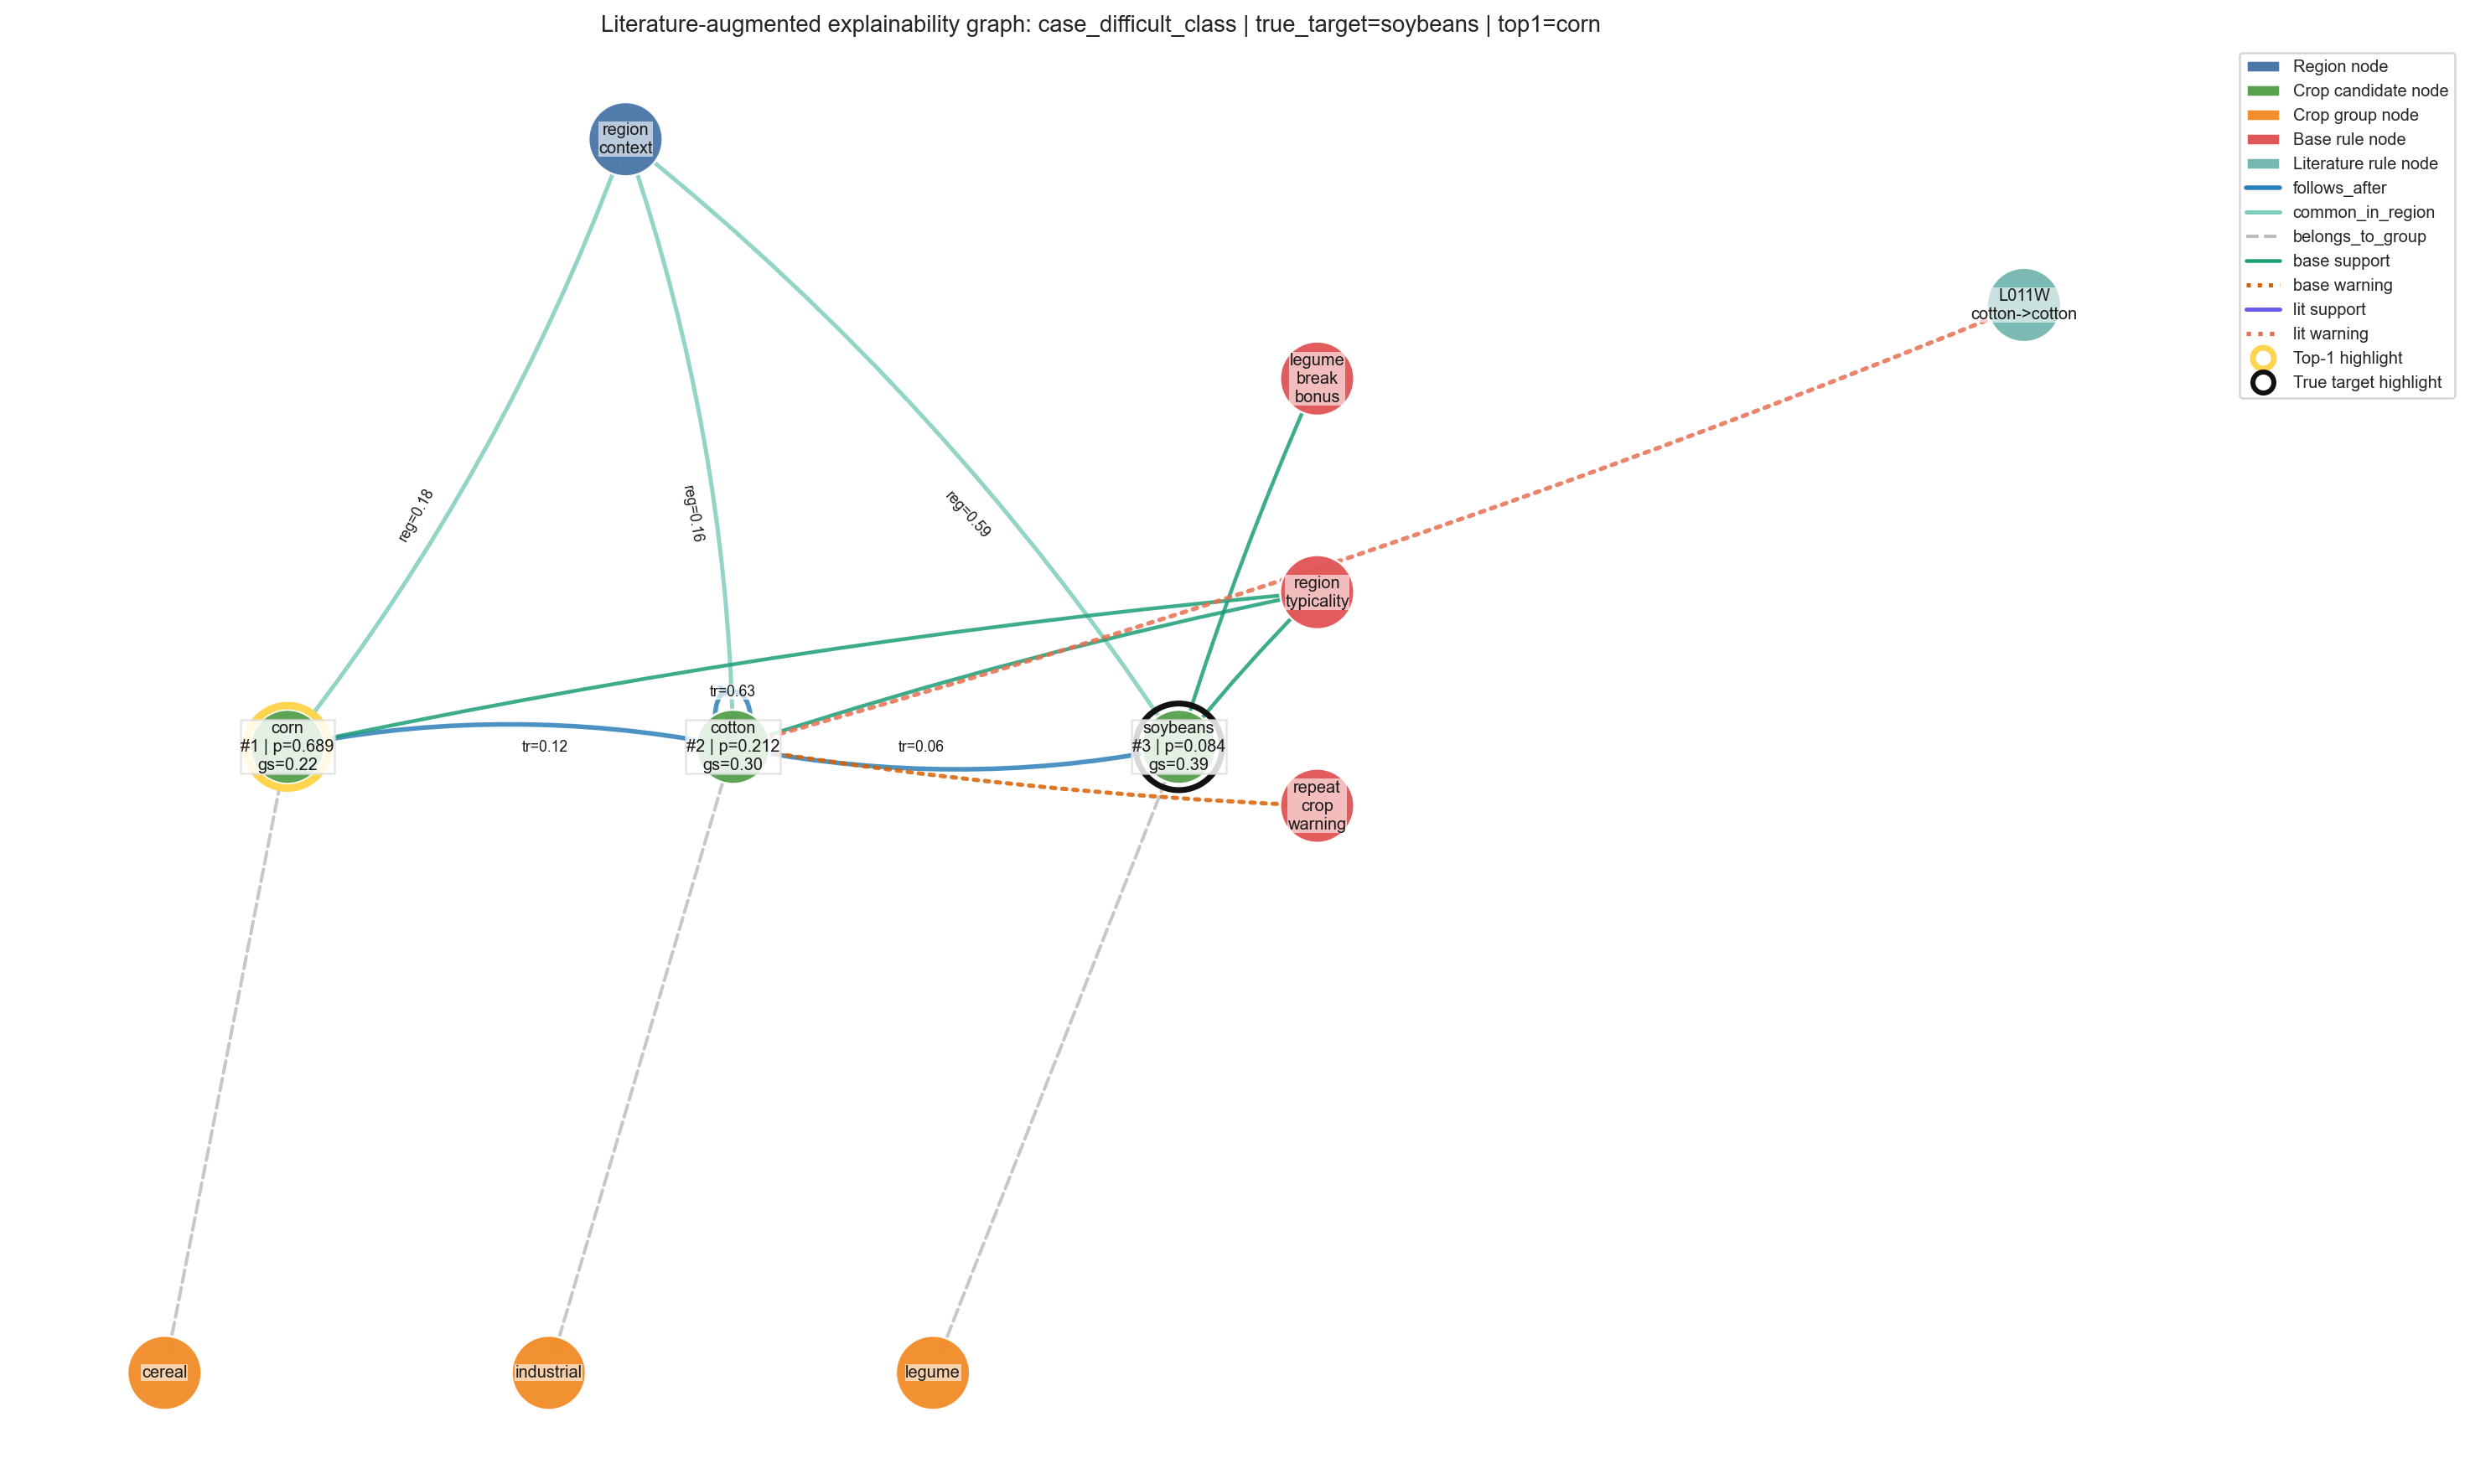

Comparison figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\base_vs_literature_graph_support.png


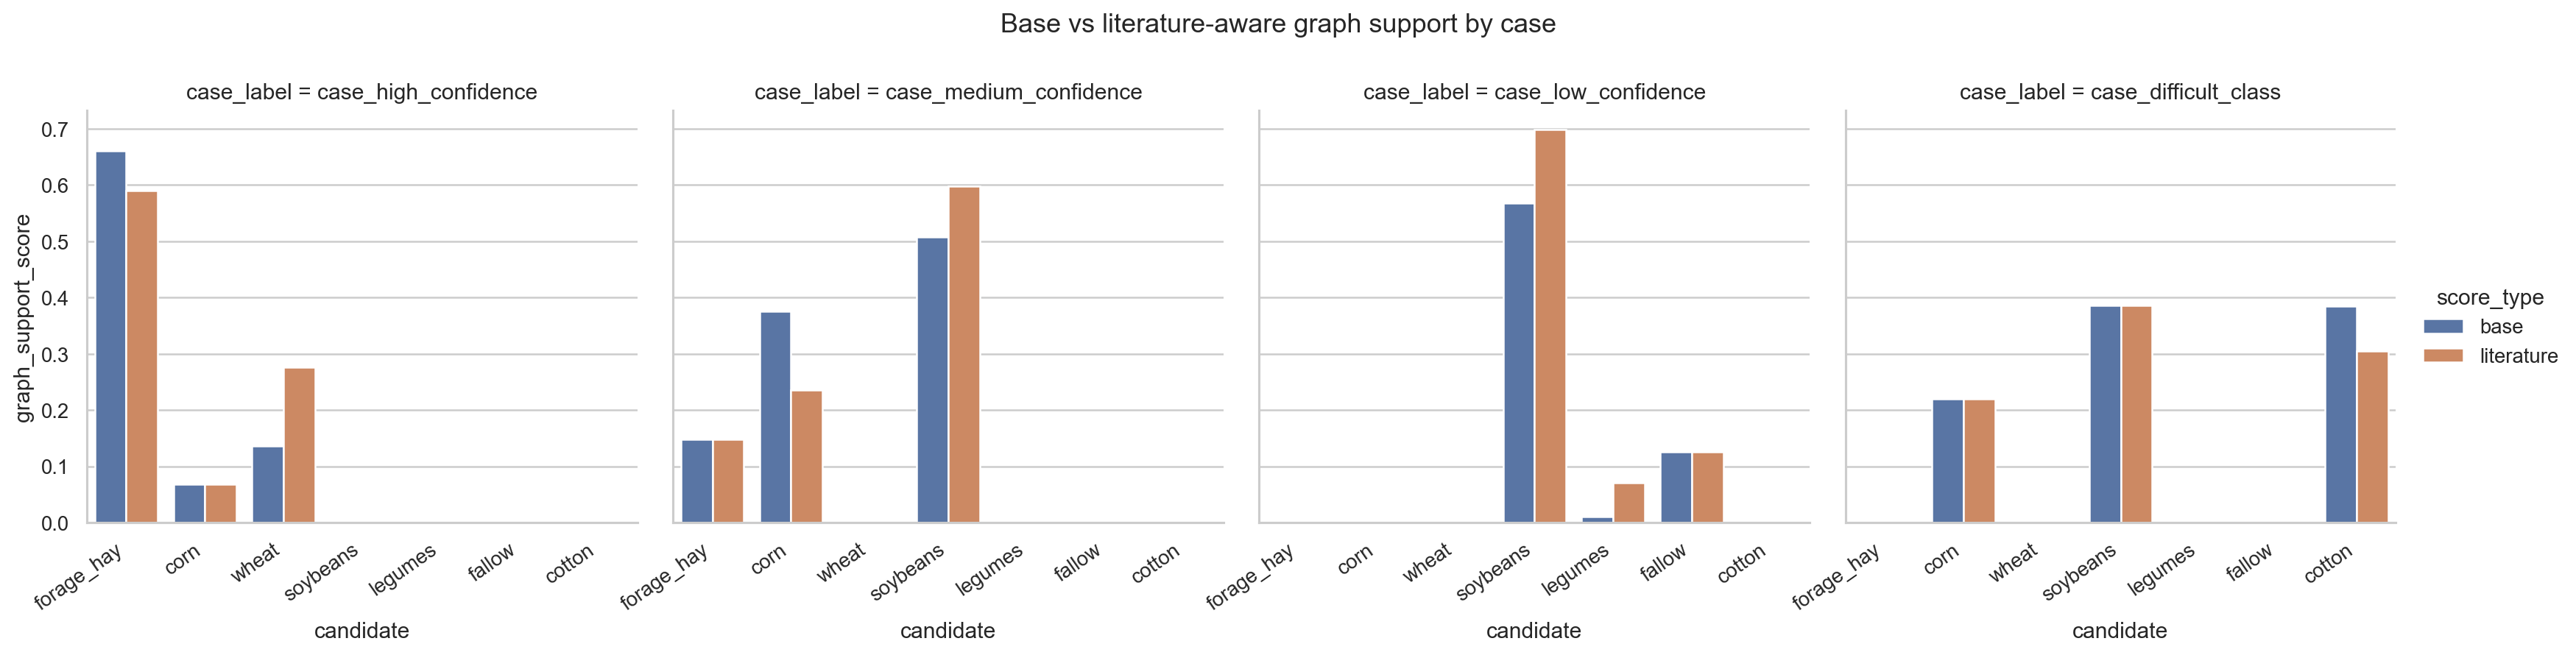

In [15]:
group_values = sorted({g for g in CROP_TO_GROUP.values() if pd.notna(g)})
base_node_ids = set(kg_nodes_df["node_id"])

group_nodes = []
for group_name in group_values:
    node_id = f"group_{group_name}"
    if node_id not in base_node_ids:
        group_nodes.append({
            "node_id": node_id,
            "node_type": "CropGroup",
            "name": group_name,
            "display_name": f"group:{group_name}",
            "metadata_json": json.dumps({"group_name": group_name}, ensure_ascii=False),
        })

source_nodes = []
for meta in SOURCE_META:
    source_nodes.append({
        "node_id": f"source_{meta['source_id']}",
        "node_type": "LiteratureSource",
        "name": meta["source_id"],
        "display_name": meta["citation"],
        "metadata_json": json.dumps(meta, ensure_ascii=False),
    })

rule_nodes = []
for _, rule in literature_rules_df.iterrows():
    rule_nodes.append({
        "node_id": f"litrule_{rule['rule_id']}",
        "node_type": "LiteratureRule",
        "name": rule["rule_id"],
        "display_name": rule["source_title_short"],
        "metadata_json": json.dumps(rule.to_dict(), ensure_ascii=False),
    })

literature_graph_nodes_df = pd.concat(
    [kg_nodes_df, pd.DataFrame(group_nodes), pd.DataFrame(source_nodes), pd.DataFrame(rule_nodes)],
    ignore_index=True,
)

def resolve_context_node(context_value: str) -> str:
    if str(context_value).startswith("group:"):
        return f"group_{str(context_value).split(':', 1)[1]}"
    return f"crop_{context_value}"

literature_edges = []
for _, rule in literature_rules_df.iterrows():
    rule_node_id = f"litrule_{rule['rule_id']}"
    source_node_id = f"source_{rule['source_id']}"
    context_node_id = resolve_context_node(rule["crop_context"])
    candidate_node_id = resolve_context_node(rule["candidate"])
    literature_edges.extend([
        {
            "source_id": source_node_id,
            "target_id": rule_node_id,
            "edge_type": "documents_rule",
            "weight": 1.0,
            "support": 1.0,
            "note": "literature source documents literature rule",
        },
        {
            "source_id": context_node_id,
            "target_id": rule_node_id,
            "edge_type": "literature_context",
            "weight": 1.0,
            "support": 1.0,
            "note": f"literature context from {rule['source_id']}",
        },
        {
            "source_id": rule_node_id,
            "target_id": candidate_node_id,
            "edge_type": f"literature_{normalize_signal_type(rule['signal_type'])}",
            "weight": float(LITERATURE_STRENGTH_WEIGHTS.get(str(rule['strength']).lower(), 0.0)),
            "support": 1.0,
            "note": f"literature evidence from {rule['source_id']}",
        },
    ])

literature_graph_edges_df = pd.concat([kg_edges_df, pd.DataFrame(literature_edges)], ignore_index=True)

def shorten_rule_label(rule_id: str, source_id: str, crop_context: str, candidate: str, signal_type: str) -> str:
    rid = str(rule_id).replace("lit_rule_", "L")
    signal = "S" if normalize_signal_type(signal_type) == "support" else "W"
    ctx = str(crop_context).replace("group:", "g:")
    cand = str(candidate).replace("group:", "g:")
    if len(ctx) > 10:
        ctx = ctx[:10]
    if len(cand) > 10:
        cand = cand[:10]
    return f"{rid}{signal}\n{ctx}->{cand}"

def draw_case_literature_graph(case_label: str, cdf: pd.DataFrame, save_path: Path) -> None:
    cdf = cdf.sort_values(["candidate_rank", "score"]).copy()
    last_crop = str(cdf["last_crop"].iloc[0])
    top1_candidate = str(cdf.loc[cdf["is_model_top1"], "candidate"].iloc[0]) if not cdf.empty else None
    true_target = str(cdf.loc[cdf["is_true_target"], "candidate"].iloc[0]) if cdf["is_true_target"].any() else None
    G = nx.DiGraph()
    region_node = f"region_{case_label}"
    last_crop_node = f"crop_{last_crop}"
    G.add_node(region_node, node_type="Region", label="region\ncontext")
    G.add_node(last_crop_node, node_type="Crop", label=f"last:{last_crop}")

    for row in cdf.to_dict(orient="records"):
        cand = str(row["candidate"])
        cand_node = f"crop_{cand}"
        group_name = str(row["candidate_group_mapped"])
        group_node = f"group_{group_name}"
        cand_label = f"{cand}\n#{int(row['candidate_rank'])} | p={float(row['score']):.3f}\ngs={float(row['literature_graph_support_score']):.2f}"
        G.add_node(
            cand_node,
            node_type="Crop",
            label=cand_label,
            is_candidate=True,
            is_top1=bool(row["is_model_top1"]),
            is_true_target=bool(row["is_true_target"]),
        )
        G.add_node(group_node, node_type="CropGroup", label=group_name)
        G.add_edge(cand_node, group_node, edge_type="belongs_to_group", weight=1.0)
        if not pd.isna(row["transition_prob"]):
            G.add_edge(last_crop_node, cand_node, edge_type="follows_after", weight=float(row["transition_prob"]))
        if not pd.isna(row["region_share"]):
            G.add_edge(region_node, cand_node, edge_type="common_in_region", weight=float(row["region_share"]))

        for flag in list(row["support_flags"]):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag.replace("_", "\n"))
            G.add_edge(rule_node, cand_node, edge_type="supports_candidate", weight=1.0)
        for flag in list(row["warning_flags"]):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag.replace("_", "\n"))
            G.add_edge(rule_node, cand_node, edge_type="warns_about_candidate", weight=1.0)

        matched_rule_ids = list(row["literature_support_flags"]) + list(row["literature_warning_flags"])
        for rule_id in matched_rule_ids:
            rule_row = literature_rules_df.loc[literature_rules_df["rule_id"] == rule_id].iloc[0]
            lit_rule_node = f"litrule_{rule_id}"
            G.add_node(
                lit_rule_node,
                node_type="LiteratureRule",
                label=shorten_rule_label(rule_id, rule_row['source_id'], rule_row['crop_context'], rule_row['candidate'], rule_row['signal_type'])
            )
            lit_edge_type = "literature_supports_candidate" if normalize_signal_type(rule_row['signal_type']) == "support" else "literature_warns_about_candidate"
            G.add_edge(lit_rule_node, cand_node, edge_type=lit_edge_type, weight=float(LITERATURE_STRENGTH_WEIGHTS.get(str(rule_row['strength']).lower(), 0.0)))

    pos = {}
    pos[region_node] = (0.0, 2.1)
    pos[last_crop_node] = (-2.8, 1.0)
    candidate_nodes = [f"crop_{str(c)}" for c in cdf["candidate"].astype(str).tolist()]
    for i, node in enumerate(candidate_nodes):
        pos[node] = (-1.1 + i * 1.45, 0.45)
    group_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "CropGroup"])
    for i, node in enumerate(group_nodes):
        pos[node] = (-1.5 + i * 1.25, -1.25)
    base_rule_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "Rule"])
    for i, node in enumerate(base_rule_nodes):
        pos[node] = (2.25, 1.45 - i * 0.58)
    lit_rule_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "LiteratureRule"])
    for i, node in enumerate(lit_rule_nodes):
        pos[node] = (4.55, 1.65 - i * 0.72)
    plt.figure(figsize=(16.5, 10.0))
    labels = {}
    node_colors = []
    for n, d in G.nodes(data=True):
        labels[n] = d.get("label", n)
        ntype = d.get("node_type", "Other")
        if ntype == "Region":
            node_colors.append("#4C78A8")
        elif ntype == "Crop":
            node_colors.append("#59A14F")
        elif ntype == "CropGroup":
            node_colors.append("#F28E2B")
        elif ntype == "Rule":
            node_colors.append("#E15759")
        elif ntype == "LiteratureRule":
            node_colors.append("#76B7B2")
        else:
            node_colors.append("#BDBDBD")
    nx.draw_networkx_nodes(
        G, pos, nodelist=list(G.nodes()), node_color=node_colors, node_size=1250,
        edgecolors="#FFFFFF", linewidths=1.0, alpha=0.97,
    )
    non_candidate_labels = {n: lbl for n, lbl in labels.items() if n not in set(candidate_nodes)}
    candidate_labels = {n: labels[n] for n in candidate_nodes if n in labels}
    nx.draw_networkx_labels(
        G, pos, labels=non_candidate_labels, font_size=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.60, "pad": 0.2}
    )
    nx.draw_networkx_labels(
        G, pos, labels=candidate_labels, font_size=8,
        bbox={"facecolor": "white", "edgecolor": "#E0E0E0", "alpha": 0.84, "pad": 0.25}
    )
    top1_nodes = [n for n, d in G.nodes(data=True) if d.get("is_top1", False)]
    true_nodes = [n for n, d in G.nodes(data=True) if d.get("is_true_target", False)]
    both_nodes = [n for n in top1_nodes if n in set(true_nodes)]
    if top1_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=top1_nodes, node_color="none", node_size=1550, edgecolors="#FFD54F", linewidths=3.6)
    if true_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=true_nodes, node_color="none", node_size=1710, edgecolors="#111111", linewidths=2.8)
    if both_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=both_nodes, node_color="none", node_size=1880, edgecolors="#C62828", linewidths=2.4)

    edge_groups = {
        "follows_after": {"color": "#2C7FB8", "style": "solid", "width": 2.2, "connectionstyle": "arc3,rad=0.10"},
        "common_in_region": {"color": "#7FCDBB", "style": "solid", "width": 2.0, "connectionstyle": "arc3,rad=-0.08"},
        "belongs_to_group": {"color": "#BDBDBD", "style": "dashed", "width": 1.6, "connectionstyle": "arc3,rad=0.0"},
        "supports_candidate": {"color": "#1B9E77", "style": "solid", "width": 1.8, "connectionstyle": "arc3,rad=0.03"},
        "warns_about_candidate": {"color": "#D95F02", "style": "dotted", "width": 2.0, "connectionstyle": "arc3,rad=-0.03"},
        "documents_rule": {"color": "#9C6DB0", "style": "solid", "width": 1.4, "connectionstyle": "arc3,rad=0.0"},
        "literature_supports_candidate": {"color": "#6C5CE7", "style": "solid", "width": 2.0, "connectionstyle": "arc3,rad=0.03"},
        "literature_warns_about_candidate": {"color": "#E76F51", "style": "dotted", "width": 2.1, "connectionstyle": "arc3,rad=-0.03"},
    }
    for edge_type, style in edge_groups.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == edge_type]
        if edgelist:
            nx.draw_networkx_edges(
                G, pos, edgelist=edgelist, arrows=True, arrowstyle="->",
                edge_color=style["color"], style=style["style"], width=style["width"], alpha=0.85,
                connectionstyle=style["connectionstyle"]
            )
    follows_labels = {}
    region_labels = {}
    for u, v, d in G.edges(data=True):
        et = d.get("edge_type", "")
        w = d.get("weight")
        if w is None:
            continue
        if et == "follows_after":
            follows_labels[(u, v)] = f"tr={float(w):.2f}"
        elif et == "common_in_region":
            region_labels[(u, v)] = f"reg={float(w):.2f}"
    label_box = {"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.15}
    if follows_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=follows_labels, font_size=7, label_pos=0.42, bbox=label_box, rotate=True)
    if region_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=region_labels, font_size=7, label_pos=0.62, bbox=label_box, rotate=True)
    legend_handles = [
        Patch(facecolor="#4C78A8", edgecolor="#FFFFFF", label="Region node"),
        Patch(facecolor="#59A14F", edgecolor="#FFFFFF", label="Crop candidate node"),
        Patch(facecolor="#F28E2B", edgecolor="#FFFFFF", label="Crop group node"),
        Patch(facecolor="#E15759", edgecolor="#FFFFFF", label="Base rule node"),
        Patch(facecolor="#76B7B2", edgecolor="#FFFFFF", label="Literature rule node"),
        Line2D([0], [0], color="#2C7FB8", lw=2.2, linestyle="solid", label="follows_after"),
        Line2D([0], [0], color="#7FCDBB", lw=2.0, linestyle="solid", label="common_in_region"),
        Line2D([0], [0], color="#BDBDBD", lw=1.6, linestyle="--", label="belongs_to_group"),
        Line2D([0], [0], color="#1B9E77", lw=1.8, linestyle="solid", label="base support"),
        Line2D([0], [0], color="#D95F02", lw=2.0, linestyle=":", label="base warning"),
        Line2D([0], [0], color="#6C5CE7", lw=2.0, linestyle="solid", label="lit support"),
        Line2D([0], [0], color="#E76F51", lw=2.1, linestyle=":", label="lit warning"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#FFD54F", markeredgewidth=2.8, lw=0, label="Top-1 highlight"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#111111", markeredgewidth=2.4, lw=0, label="True target highlight"),
    ]
    plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=8)
    plt.title(f"Literature-augmented explainability graph: {case_label} | true_target={true_target} | top1={top1_candidate}", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close()

case_figure_paths = []
for case_label, cdf in literature_augmented_case_explanations_df.groupby("case_label", sort=False):
    fig_path = FIGURES_DIR / f"{case_label}_literature_graph.png"
    draw_case_literature_graph(case_label, cdf, fig_path)
    case_figure_paths.append((case_label, fig_path))

plot_df = comparison_df.melt(
    id_vars=["case_label", "candidate"],
    value_vars=["base_graph_support_score", "literature_graph_support_score"],
    var_name="score_type",
    value_name="graph_support_score",
)
plot_df["score_type"] = plot_df["score_type"].map({
    "base_graph_support_score": "base",
    "literature_graph_support_score": "literature",
})

g = sns.catplot(
    data=plot_df,
    x="candidate",
    y="graph_support_score",
    hue="score_type",
    col="case_label",
    kind="bar",
    sharey=True,
    height=4.6,
    aspect=1.0,
)
g.set_xticklabels(rotation=35, ha="right")
g.figure.subplots_adjust(top=0.82)
g.figure.suptitle("Base vs literature-aware graph support by case")
comparison_figure_path = FIGURES_DIR / "base_vs_literature_graph_support.png"
g.savefig(comparison_figure_path, dpi=180, bbox_inches="tight")
plt.close(g.figure)

literature_augmented_case_explanations_df.to_csv(RESULTS_DIR / "literature_augmented_case_explanations.csv", index=False)
literature_augmented_case_summary_df.to_csv(RESULTS_DIR / "literature_augmented_case_summary.csv", index=False)
comparison_df.to_csv(RESULTS_DIR / "literature_vs_base_case_comparison.csv", index=False)
literature_graph_nodes_df.to_csv(RESULTS_DIR / "literature_graph_nodes.csv", index=False)
literature_graph_edges_df.to_csv(RESULTS_DIR / "literature_graph_edges.csv", index=False)

run_meta = {
    "base_stage": "09_knowledge_graph_explainability",
    "cases_count": int(literature_augmented_case_summary_df["case_label"].nunique()),
    "base_case_rows": int(len(case_explanations_df)),
    "literature_rules_count": int(len(literature_rules_df)),
    "literature_sources_count": int(len(SOURCE_META)),
    "nodes_count": int(len(literature_graph_nodes_df)),
    "edges_count": int(len(literature_graph_edges_df)),
    "alignment_distribution": literature_augmented_case_summary_df["literature_top1_graph_alignment"].value_counts(dropna=False).to_dict(),
    "input_run_meta": base_run_meta,
}
with (RESULTS_DIR / "run_meta.json").open("w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

print("Saved literature-aware outputs to:", RESULTS_DIR)
display(literature_augmented_case_summary_df)

print("Inline case-study figures:")
for case_label, fig_path in case_figure_paths:
    print(f"- {case_label}: {fig_path}")
    ipy_display(IPImage(filename=str(fig_path)))

print("Comparison figure:", comparison_figure_path)
ipy_display(IPImage(filename=str(comparison_figure_path)))


## Анализ результатов literature-aware graph

По результатам stage 12 литературные правила **не изменили** итоговое распределение case-level alignment по четырем выбранным кейсам:

- `case_high_confidence`: `strong -> strong`
- `case_medium_confidence`: `weak -> weak`
- `case_low_confidence`: `weak -> weak`
- `case_difficult_class`: `weak -> weak`

Это означает, что в текущем наборе case studies литература **не дала формального улучшения alignment-метрики**, если смотреть только на итоговые категории `strong / medium / weak`.

При этом литература не конфликтует с исходным explainability-слоем, а работает как **корректирующий интерпретационный слой**:

- усиливает ротационно правдоподобные альтернативы, например `soybeans` после `corn`;
- ослабляет повторные или менее желательные переходы, например `corn -> corn` и `cotton -> cotton`;
- усиливает кандидатов, согласованных с логикой сильных предшественников, например `wheat` после травяного или парового звена.

На уровне candidate-level score это видно лучше, чем на уровне case-level alignment:

- средняя дельта `gs` по всем candidate-rows положительная;
- у `top-1` кандидатов средняя дельта в текущих кейсах отрицательная;
- у альтернативных кандидатов средняя дельта положительная.

Следовательно, литературные источники в этой конфигурации работают **не как усилитель текущего top-1**, а как более консервативный semantic correction layer, который:

- штрафует нежелательные повторы;
- усиливает ротационно правдоподобные альтернативы;
- делает shortlist более интерпретируемым.

Итоговая интерпретация для дипломной логики такова:

- литературные правила **согласованы** с исходным explainability-графом;
- литературные правила **полезны** как дополнительный explainability-контекст;
- на текущих 4 кейсах они **не улучшают формально alignment-метрику**, но **улучшают содержательную интерпретацию shortlist**.


## Краткие выводы по этапу

- Stage `12` не меняет модель и не переопределяет shortlist из `09`.
- Новый literature-aware graph добавляет русскоязычные support/warning signals как отдельный слой evidence.
- Для тех же 4 кейсов теперь можно сравнивать `base_graph_support_score` и `literature_graph_support_score` и видеть, какие литературные правила сработали.
- Для `cotton` в текущей версии добавлены прямые literature-backed правила, но они остаются зонально ограниченными и должны читаться вместе с `zonal_note`.
